### Validity

Run 5 models 

#### Berlin earlier time slot, predictive models

In [38]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from matplotlib import pyplot as plt


In [39]:
# Load the cleaned datasets
df_berlin_q1 = pd.read_csv("../data/processed/berlin_2025_Q1_clean.csv")
df_geneva = pd.read_csv("../data/processed/geneva_2025_clean.csv")

In [40]:
#  Berlin 2025 Q1 
df_berlin_q1 = pd.read_csv("../data/processed/berlin_2025_Q1_clean.csv")

y_berlin = df_berlin_q1["log_price"]
X_berlin = df_berlin_q1.drop(columns=["price", "log_price"])

X_berlin = pd.get_dummies(X_berlin, drop_first=True)
X_berlin = X_berlin.apply(pd.to_numeric, errors="coerce")
X_berlin = X_berlin.fillna(X_berlin.median())

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_berlin, y_berlin, test_size=0.2, random_state=42
)

In [41]:
# OLS Berlin
Xb_train_ols = sm.add_constant(Xb_train.to_numpy(dtype=float))
Xb_test_ols = sm.add_constant(Xb_test.to_numpy(dtype=float))

yb_train_np = yb_train.to_numpy(dtype=float)
yb_test_np = yb_test.to_numpy(dtype=float)

ols_b = sm.OLS(yb_train_np, Xb_train_ols).fit()
yb_pred_ols = ols_b.predict(Xb_test_ols)

rmse_ols_b = np.sqrt(mean_squared_error(yb_test_np, yb_pred_ols))
r2_ols_b = r2_score(yb_test_np, yb_pred_ols)

In [42]:
# Lasso Berlin
scaler_b = StandardScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)

lasso_b = LassoCV(cv=5, random_state=42)
lasso_b.fit(Xb_train_s, yb_train)

yb_pred_lasso = lasso_b.predict(Xb_test_s)

rmse_lasso_b = np.sqrt(mean_squared_error(yb_test, yb_pred_lasso))
r2_lasso_b = r2_score(yb_test, yb_pred_lasso)

In [43]:
# Random Forest Berlin
rf_b = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_b.fit(Xb_train, yb_train)

yb_pred_rf = rf_b.predict(Xb_test)

rmse_rf_b = np.sqrt(mean_squared_error(yb_test, yb_pred_rf))
r2_rf_b = r2_score(yb_test, yb_pred_rf)

In [44]:
# Gradient Boosting Berlin
gbr_b = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
gbr_b.fit(Xb_train, yb_train)

yb_pred_gbr = gbr_b.predict(Xb_test)

rmse_gbr_b = np.sqrt(mean_squared_error(yb_test, yb_pred_gbr))
r2_gbr_b = r2_score(yb_test, yb_pred_gbr)

In [45]:
# Elastic Net Berlin
enet_b = ElasticNetCV(cv=5, random_state=42)
enet_b.fit(Xb_train_s, yb_train)

yb_pred_enet = enet_b.predict(Xb_test_s)

rmse_enet_b = np.sqrt(mean_squared_error(yb_test, yb_pred_enet))
r2_enet_b = r2_score(yb_test, yb_pred_enet)

In [46]:
# Berlin horserace table
results_berlin = pd.DataFrame({
    "Model": ["OLS", "LASSO", "Random Forest", "Gradient Boosting", "Elastic Net"],
    "RMSE": [rmse_ols_b, rmse_lasso_b, rmse_rf_b, rmse_gbr_b, rmse_enet_b],
    "R_squared": [r2_ols_b, r2_lasso_b, r2_rf_b, r2_gbr_b, r2_enet_b]
})

results_berlin

,Model,RMSE,R_squared
0,OLS,0.468589,0.418391
1,LASSO,0.468572,0.418433
2,Random Forest,0.428148,0.514450
3,Gradient Boosting,0.422799,0.526507
4,Elastic Net,0.468570,0.418438


The results indicate a clear performance gap between linear and tree-based models. OLS, LASSO, and Elastic Net all perform almost identically, with RMSE values around 0.47 and R² close to 0.42, suggesting that linear approaches capture only part of the variation in Airbnb prices. 

In contrast, the tree-based models deliver substantially better predictive accuracy. Random Forest and Gradient Boosting both reduce prediction error and explain a larger share of price variation, with Gradient Boosting performing best overall. This pattern suggests that Airbnb prices depend on nonlinear relationships and interactions between listing characteristics, which are better captured by more flexible models. From a business perspective, these results indicate that tree-based models are more suitable for pricing decisions than linear specifications.

#### Geneva prediction models

In [47]:
# Geneva 
df_geneva = pd.read_csv("../data/processed/geneva_2025_clean.csv")

y_g = df_geneva["log_price"]
X_g = df_geneva.drop(columns=["price", "log_price"])

X_g = pd.get_dummies(X_g, drop_first=True)
X_g = X_g.apply(pd.to_numeric, errors="coerce")
X_g = X_g.fillna(X_g.median())

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=42
)


In [48]:
# OLS Geneva
Xg_train_ols = sm.add_constant(Xg_train.to_numpy(dtype=float))
Xg_test_ols = sm.add_constant(Xg_test.to_numpy(dtype=float))

yg_train_np = yg_train.to_numpy(dtype=float)
yg_test_np = yg_test.to_numpy(dtype=float)

ols_g = sm.OLS(yg_train_np, Xg_train_ols).fit()
yg_pred_ols = ols_g.predict(Xg_test_ols)

rmse_ols_g = np.sqrt(mean_squared_error(yg_test_np, yg_pred_ols))
r2_ols_g = r2_score(yg_test_np, yg_pred_ols)

In [49]:
# Lasso Geneva
scaler_g = StandardScaler()
Xg_train_s = scaler_g.fit_transform(Xg_train)
Xg_test_s = scaler_g.transform(Xg_test)

lasso_g = LassoCV(cv=5, random_state=42)
lasso_g.fit(Xg_train_s, yg_train)

yg_pred_lasso = lasso_g.predict(Xg_test_s)

rmse_lasso_g = np.sqrt(mean_squared_error(yg_test, yg_pred_lasso))
r2_lasso_g = r2_score(yg_test, yg_pred_lasso)

In [50]:
# Random Forest Geneva
rf_g = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_g.fit(Xg_train, yg_train)
yg_pred_rf = rf_g.predict(Xg_test)

rmse_rf_g = np.sqrt(mean_squared_error(yg_test, yg_pred_rf))
r2_rf_g = r2_score(yg_test, yg_pred_rf)

In [51]:
# Gradient Boosting Geneva
gbr_g = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

gbr_g.fit(Xg_train, yg_train)
yg_pred_gbr = gbr_g.predict(Xg_test)

rmse_gbr_g = np.sqrt(mean_squared_error(yg_test, yg_pred_gbr))
r2_gbr_g = r2_score(yg_test, yg_pred_gbr)

In [52]:
# Elastic Net Geneva
enet_g = ElasticNetCV(cv=5, random_state=42)
enet_g.fit(Xg_train_s, yg_train)

yg_pred_enet = enet_g.predict(Xg_test_s)

rmse_enet_g = np.sqrt(mean_squared_error(yg_test, yg_pred_enet))
r2_enet_g = r2_score(yg_test, yg_pred_enet)

In [53]:
# Geneva horserace table
results_geneva = pd.DataFrame({
    "Model": ["OLS", "LASSO", "Random Forest", "Gradient Boosting", "Elastic Net"],
    "RMSE": [rmse_ols_g, rmse_lasso_g, rmse_rf_g, rmse_gbr_g, rmse_enet_g],
    "R_squared": [r2_ols_g, r2_lasso_g, r2_rf_g, r2_gbr_g, r2_enet_g]
})

results_geneva


,Model,RMSE,R_squared
0,OLS,0.391068,0.529740
1,LASSO,0.391019,0.529858
2,Random Forest,0.413918,0.473180
3,Gradient Boosting,0.397207,0.514858
4,Elastic Net,0.391006,0.529888


In the Geneva dataset, the linear models perform notably better than in the Berlin case, with OLS, LASSO, and Elastic Net achieving the lowest prediction errors and explaining over half of the variation in prices. This suggests that price formation in Geneva is more linear and structured, making it easier for simpler models to capture key relationships.

While tree-based models still perform reasonably well, they do not provide the same improvement as observed for Berlin. From a business perspective, this indicates that simpler, more interpretable pricing models may be sufficient for Geneva, whereas more complex machine-learning approaches add limited additional value in this market.

#### Extra task

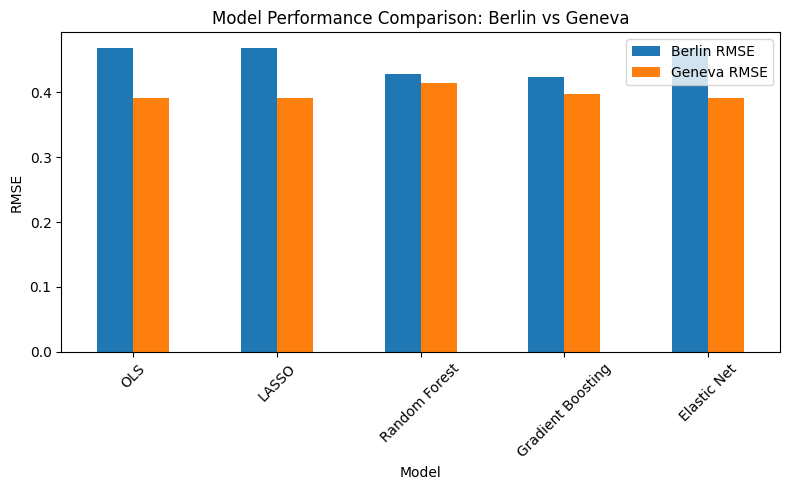

In [54]:
from matplotlib import pyplot as plt


comparison_df = pd.DataFrame({
    "Model": ["OLS", "LASSO", "Random Forest", "Gradient Boosting", "Elastic Net"],
    "Berlin RMSE": results_berlin["RMSE"].values,
    "Geneva RMSE": results_geneva["RMSE"].values
})

comparison_df


comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)
plt.ylabel("RMSE")
plt.title("Model Performance Comparison: Berlin vs Geneva")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()